## VAE 모델 구조 스크래치 코드

하이퍼파라메터 정의

In [2]:
"""
VAE (Variational Autoencoder) Scratch Implementation

Dataset: MNIST (1998, Yann LeCun) - 60K train, 10K test, 28×28 → 64×64
Stable Diffusion VAE: AutoencoderKL (512×512 → 64×64, 8배 압축)

Core: Encoder → (μ,σ) → Reparameterize (z=μ+σ*ε) → Decoder → Image
Loss: Reconstruction (MSE) + KL Divergence
"""
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import os

# 현재 파일이 있는 폴더에 결과 저장
SCRIPT_DIR = "./"

IMG_SIZE = 64
LATENT_DIM = 128
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
EPOCHS = 20
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


학습 데이터셋 로딩

In [3]:
transform = transforms.Compose([
	transforms.Resize((IMG_SIZE, IMG_SIZE)),
	transforms.ToTensor(),
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)



VAE 모델 구조 정의

<div style="font-size: 90%;">

인코더(Encoder) 출력 벡터 계산

입력 데이터 $\mathbf{x}$를 받아 Fully Connected Layer를 통과시켜 평균과 로그 분산을 각각 계산.

$$ \boldsymbol{\mu} = \text{fc}_{\mu}(\mathbf{x}) $$
$$ \log(\boldsymbol{\sigma}^2) = \text{fc}_{\log\text{var}}(\mathbf{x}) $$

* $\boldsymbol{\mu}$: 잠재 변수(Latent Variable)의 평균 (Mean)
* $\log(\boldsymbol{\sigma}^2)$: 잠재 변수의 분산에 로그를 취한 값 (Log Variance)

</div>

In [4]:
class VAEEncoder(nn.Module):
	"""Encoder: Image → (μ, log_var)"""
	def __init__(self, latent_dim=LATENT_DIM):
		super().__init__()
		self.encoder = nn.Sequential(
			nn.Conv2d(1, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(),
			nn.Conv2d(32, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
			nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
			nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(),
		)
		self.flatten_dim = 256 * 4 * 4
		self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
		self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)
	
	def forward(self, x):
		x = self.encoder(x)
		x = x.view(x.size(0), -1)
		return self.fc_mu(x), self.fc_logvar(x)

class VAEDecoder(nn.Module):
	"""Decoder: Latent → Image"""
	def __init__(self, latent_dim=LATENT_DIM):
		super().__init__()
		self.flatten_dim = 256 * 4 * 4
		self.fc = nn.Linear(latent_dim, self.flatten_dim)
		self.decoder = nn.Sequential(
			nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
			nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
			nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(),
			nn.ConvTranspose2d(32, 1, 4, 2, 1), nn.Sigmoid(),
		)
	
	def forward(self, z):
		x = self.fc(z)
		x = x.view(x.size(0), 256, 4, 4)
		return self.decoder(x)


<div style="font-size: 90%;">

재매개변수화 트릭 (Reparameterization Trick)

신경망의 미분(역전파)이 가능하도록, 무작위 노이즈 $\boldsymbol{\epsilon}$을 표준 정규 분포에서 샘플링한 후, 구해놓은 평균 $\boldsymbol{\mu}$와 표준편차 $\boldsymbol{\sigma}$를 더하고 곱해주는 방식.

표준편차 $\boldsymbol{\sigma}$ 계산 (로그 분산을 지수 변환 후 절반으로 나누어 제곱근 효과)
$$ \boldsymbol{\sigma} = \exp\left(\frac{1}{2} \log \boldsymbol{\sigma}^2\right) $$

노이즈 샘플링 (표준 정규 분포)
$$ \boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I}) $$

잠재 벡터 $\mathbf{z}$ 생성
$$ \mathbf{z} = \boldsymbol{\mu} + \boldsymbol{\sigma} \odot \boldsymbol{\epsilon} $$
*(여기서 $\odot$은 원소별 곱셈(Element-wise multiplication)을 의미)*

---

전체 신경망 흐름 (Forward Pass)

입력 이미지 $\mathbf{x}$가 인코더를 거쳐 잠재 공간의 $\mathbf{z}$로 압축된 후, 다시 디코더를 통해 복원된 이미지 $\hat{\mathbf{x}}$로 출력되는 전체 과정.

$$ \boldsymbol{\mu}, \log\boldsymbol{\sigma}^2 = \text{Encoder}(\mathbf{x}) $$
$$ \mathbf{z} = \text{Reparameterize}(\boldsymbol{\mu}, \log\boldsymbol{\sigma}^2) $$
$$ \hat{\mathbf{x}} = \text{Decoder}(\mathbf{z}) $$

</div>

In [5]:
class VAE(nn.Module):
	"""VAE: Encoder → Reparameterize → Decoder"""
	def __init__(self, latent_dim=LATENT_DIM):
		super().__init__()
		self.encoder = VAEEncoder(latent_dim)
		self.decoder = VAEDecoder(latent_dim)
		self.latent_dim = latent_dim
	
	def reparameterize(self, mu, logvar):
		"""z = μ + σ * ε (Reparameterization Trick)"""
		std = torch.exp(0.5 * logvar)
		eps = torch.randn_like(std)
		return mu + eps * std
	
	def forward(self, x):
		mu, logvar = self.encoder(x)
		z = self.reparameterize(mu, logvar)
		return self.decoder(z), mu, logvar
	
	def sample(self, num_samples=16):
		"""Generate from z ~ N(0,1)"""
		with torch.no_grad():
			z = torch.randn(num_samples, self.latent_dim).to(DEVICE)
		return self.decoder(z)


손실 함수 정의

<div style="font-size: 90%;"\>

VAE의 전체 손실은 원본 이미지를 얼마나 잘 복원했는지 평가하는 복원 오차(Reconstruction Loss)와, 잠재 공간의 분포를 표준 정규 분포 $\mathcal{N}(\mathbf{0}, \mathbf{I})$에 가깝게 강제하는 KL 발산(KL Divergence)의 합으로 구성.

$$ \mathcal{L}_{\text{VAE}} = \mathcal{L}_{\text{Recon}} + \beta \cdot \mathcal{L}_{\text{KLD}} $$

복원 오차 (Reconstruction Loss - MSE 기반)
$$ \mathcal{L}_{\text{Recon}} = \frac{1}{N} \sum_{i=1}^{N} \left\| \mathbf{x}_i - \hat{\mathbf{x}}_i \right\|^2 $$

KL 발산 오차 (KL Divergence)
$$ \mathcal{L}_{\text{KLD}} = -\frac{1}{2N} \sum_{i=1}^{N} \sum_{j=1}^{D} \left( 1 + \log(\sigma_{i,j}^2) - \mu_{i,j}^2 - \exp(\log\sigma_{i,j}^2) \right) $$

* $N$: 배치 크기 (Batch Size, `x.size(0)`)
* $D$: 잠재 공간(Latent Space)의 차원 수
* $\beta$: KL 가중치 (`kl_weight`, $\beta$-VAE에서 사용하는 조절 변수)

In [6]:
def vae_loss(reconstruction, x, mu, logvar, kl_weight=0.001):
	"""VAE Loss = Reconstruction (MSE) + KL Divergence"""
	recon_loss = F.mse_loss(reconstruction, x, reduction='sum') / x.size(0)
	kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
	return recon_loss + kl_weight * kld_loss, recon_loss, kld_loss


모델 학습

In [7]:
model = VAE(latent_dim=LATENT_DIM).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_losses, recon_losses, kld_losses = [], [], []

for epoch in range(EPOCHS):
	model.train()
	train_loss = train_recon = train_kld = 0
	
	for images, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
		images = images.to(DEVICE)
		reconstruction, mu, logvar = model(images)
		loss, recon_loss, kld_loss = vae_loss(reconstruction, images, mu, logvar)
		
		optimizer.zero_grad()
		loss.backward()
		optimizer.step()
		
		train_loss += loss.item()
		train_recon += recon_loss.item()
		train_kld += kld_loss.item()
	
	avg_loss = train_loss / len(train_loader)
	train_losses.append(avg_loss)
	recon_losses.append(train_recon / len(train_loader))
	kld_losses.append(train_kld / len(train_loader))
	
	print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}")

# Training curves
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].plot(train_losses); axes[0].set_title('Total Loss'); axes[0].grid()
axes[1].plot(recon_losses); axes[1].set_title('Reconstruction'); axes[1].grid()
axes[2].plot(kld_losses); axes[2].set_title('KL Divergence'); axes[2].grid()
plt.tight_layout()
plt.savefig(os.path.join(SCRIPT_DIR, 'vae_training.png'), dpi=200)
plt.close()


Epoch 1/20: 100%|██████████| 469/469 [00:11<00:00, 41.19it/s]


Epoch 1: Loss=64.4475


Epoch 2/20: 100%|██████████| 469/469 [00:10<00:00, 43.42it/s]


Epoch 2: Loss=8.4042


Epoch 3/20: 100%|██████████| 469/469 [00:17<00:00, 26.08it/s]


...

Epoch 18: Loss=2.1451


Epoch 19/20: 100%|██████████| 469/469 [00:15<00:00, 29.34it/s]


Epoch 19: Loss=2.0973


Epoch 20/20: 100%|██████████| 469/469 [00:17<00:00, 27.38it/s]


Epoch 20: Loss=2.0503


모델 평가 테스트


Generating 2D latent manifold with digit transitions...
Computing per-digit latent means...
Digit 0: 5923 samples
Digit 1: 6742 samples
Digit 2: 5958 samples
Digit 3: 6131 samples
Digit 4: 5842 samples
Digit 5: 5421 samples
Digit 6: 5918 samples
Digit 7: 6265 samples
Digit 8: 5851 samples
Digit 9: 5949 samples
✓ Saved: ./vae_latent_manifold.png

Done! Loss: 2.0503
Files saved to: ./


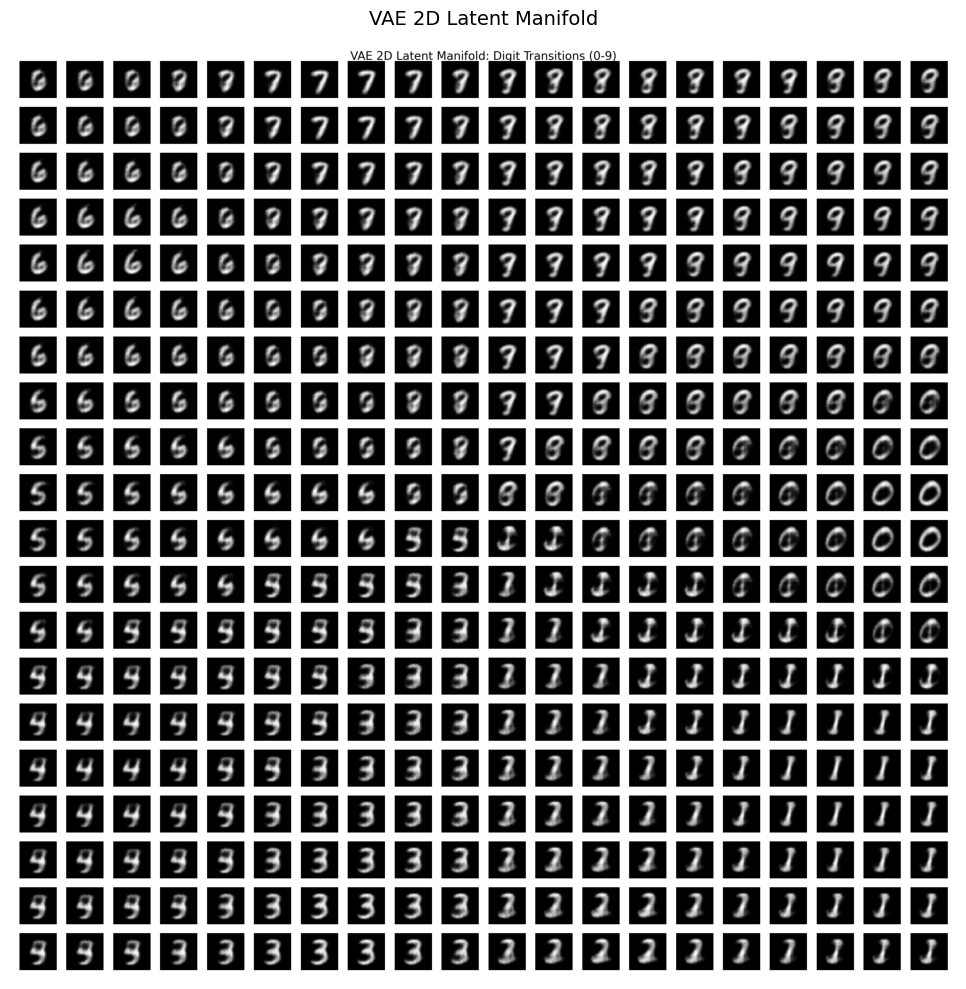

In [8]:
model.eval()
test_images, _ = next(iter(test_loader))

# Reconstruction
with torch.no_grad():
	reconstructed, _, _ = model(test_images[:8].to(DEVICE))

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
	axes[0, i].imshow(test_images[i].squeeze().numpy(), cmap='gray'); axes[0, i].axis('off')
	axes[1, i].imshow(reconstructed[i].cpu().squeeze().detach().numpy(), cmap='gray'); axes[1, i].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(SCRIPT_DIR, 'vae_reconstruction.png'), dpi=150)
plt.close()

# Generation - Latent Space 2D Manifold (올바른 방법)
print("\nGenerating 2D latent manifold with digit transitions...")

# 올바른 방법: 각 숫자(0-9)의 latent 평균을 구하고 2D 공간에 배치
print("Computing per-digit latent means...")
model.eval()

# 각 숫자별 latent 수집
digit_latents = {i: [] for i in range(10)}
with torch.no_grad():
	for images, labels in train_loader:
		images = images.to(DEVICE)
		mu, _ = model.encoder(images)
		
		for i in range(10):
			mask = labels == i
			if mask.any():
				digit_latents[i].append(mu[mask].cpu())

# 각 숫자의 평균 latent 계산
digit_means = {}
for i in range(10):
	if digit_latents[i]:
		digit_means[i] = torch.cat(digit_latents[i], dim=0).mean(dim=0)
		print(f"Digit {i}: {len(torch.cat(digit_latents[i], dim=0))} samples")

# 2D 그리드에서 숫자 배치 (0-9를 자연스럽게 배치)
# 숫자를 원형 또는 그리드 형태로 배치
n = 20  # 20×20 grid
fig, axes = plt.subplots(n, n, figsize=(16, 16))

# 10개 숫자를 2D 공간에 원형으로 배치
angles = np.linspace(0, 2*np.pi, 11)[:-1]  # 10개 각도
digit_positions = []
for i, angle in enumerate(angles):
	x = np.cos(angle)
	y = np.sin(angle)
	digit_positions.append((x, y, i))  # (x, y, digit)

for i in range(n):
	for j in range(n):
		# 그리드 좌표를 -1 ~ 1 범위로 정규화
		x = (j / (n-1)) * 2 - 1
		y = (i / (n-1)) * 2 - 1
		
		# 가장 가까운 2-3개 숫자 찾기 (거리 기반 가중치)
		distances = []
		for px, py, digit in digit_positions:
			dist = np.sqrt((x - px)**2 + (y - py)**2)
			distances.append((dist, digit))
		
		distances.sort()
		
		# 가까운 3개 숫자의 latent를 가중 평균 (Inverse Distance Weighting)
		weights = []
		digits = []
		for dist, digit in distances[:3]:
			if dist < 0.01:  # 매우 가까우면 그 숫자만 사용
				weights = [1.0]
				digits = [digit]
				break
			weight = 1.0 / (dist + 0.1)  # 작은 값 추가로 0 나누기 방지
			weights.append(weight)
			digits.append(digit)
		
		# 가중치 정규화
		weights = np.array(weights)
		weights = weights / weights.sum()
		
		# Latent 보간
		z = torch.zeros(LATENT_DIM).to(DEVICE)
		for w, d in zip(weights, digits):
			z += w * digit_means[d].to(DEVICE)
		
		# 디코딩
		with torch.no_grad():
			img = model.decoder(z.unsqueeze(0))
		
		axes[i, j].imshow(img[0].cpu().squeeze().detach().numpy(), cmap='gray')
		axes[i, j].axis('off')

plt.suptitle('VAE 2D Latent Manifold: Digit Transitions (0-9)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(SCRIPT_DIR, 'vae_latent_manifold.png'), dpi=200)
plt.close()
print(f"✓ Saved: {os.path.join(SCRIPT_DIR, 'vae_latent_manifold.png')}")

torch.save({'model': model.state_dict()}, os.path.join(SCRIPT_DIR, 'vae_mnist.pth'))
print(f"\nDone! Loss: {train_losses[-1]:.4f}")
print(f"Files saved to: {SCRIPT_DIR}")

# vae_latent_manifold image 출력
import matplotlib.pyplot as plt
img = plt.imread(os.path.join(SCRIPT_DIR, 'vae_latent_manifold.png'))
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.title('VAE 2D Latent Manifold', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()
